# 04 — Transfer learning (Keras y PyTorch)

**Qué hace:** entrena un clasificador sobre MobileNetV3Small congelado (224px), primero en Keras y luego en PyTorch. La versión PyTorch incluye además la suite completa de evaluación: métricas con `torchmetrics`, matrices de confusión (gráfica y en texto), `classification_report`, inspección visual de errores y medición de tiempo de inferencia.

**Consume:** `asl_split_nuevo/train|test|validate/<clase>/*` (producido por `02_split_por_grupos.ipynb`).

**Produce:** `model_my_tf_fine_tuned_.keras` (modelo Keras entrenado, consumido luego por `05_fine_tuning.ipynb`), `mejor_model.pth` (mejores pesos del modelo PyTorch), `matriz_confusion.png` y `matriz_confusion_numeros.png` (gráficas de la matriz de confusión).

> Nota de reorganización: `ResizeConPadding`, `entrenar_epoca` y `evaluar` se definieron originalmente en `03_cnn_desde_cero.ipynb`. Aquí se duplican tal cual para que este notebook se pueda ejecutar de forma independiente.

## Transfer learning en Keras — imports y rutas base

In [ ]:
from pathlib import Path


In [2]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

In [28]:
DESTINO = Path('./asl_split_nuevo')   
train_dir = DESTINO / 'train'
test_dir = DESTINO / 'test'
val_dir = DESTINO / 'validate'

## Carga de datos a 224px

In [29]:
trained_generated = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    batch_size = 100,
    color_mode='rgb',
    image_size=(224, 224),
    label_mode="categorical",
    pad_to_aspect_ratio=True,
)

test_generated = image_dataset_from_directory(
    test_dir,
    labels='inferred',
    batch_size = 100,
    color_mode='rgb',
    image_size=(224, 224),
    label_mode="categorical",
    pad_to_aspect_ratio=True,
)

val_generated = image_dataset_from_directory(
    val_dir,
    labels='inferred',
    batch_size = 100,
    color_mode='rgb',
    image_size=(224, 224),
    label_mode="categorical",
    pad_to_aspect_ratio=True,
)

Found 8620 files belonging to 36 classes.
Found 14517 files belonging to 36 classes.
Found 12267 files belonging to 36 classes.


## Data augmentation y backbone MobileNetV3Small congelado

In [30]:
data_augmentation = tf.keras.Sequential([
   ## tf.keras.layers.RandomRotation(0.15),
    ##tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.15),
    tf.keras.layers.RandomContrast(0.15),
])

In [31]:
pre_trained = tf.keras.applications.MobileNetV3Small(
    weights='imagenet',
    include_top = False,
    input_shape=(224, 224, 3)
)

pre_trained.trainable = False

In [32]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = pre_trained(inputs, training = False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(224, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(len(trained_generated.class_names), activation='softmax')(x)

## kernel_regularizer=tf.keras.regularizers.l2(1e-5)

model = tf.keras.Model(inputs, x)

## Compilación y entrenamiento

In [13]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 224)            │       129,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 36)             │         8,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,076,468 (4.11 MB)

 Trainable params: 137,348 (536.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [33]:
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001), loss="categorical_crossentropy", metrics=['accuracy', 'precision', 'recall'])

In [34]:
earlyStopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True 
)

In [35]:
model.fit(
    trained_generated,
    epochs=30,
    validation_data = val_generated,
    callbacks=[earlyStopping]
)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.5840 - loss: 1.7222 - precision: 0.9628 - recall: 0.2853 - val_accuracy: 0.4929 - val_loss: 1.6540 - val_precision: 0.8262 - val_recall: 0.2294
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.8958 - loss: 0.4982 - precision: 0.9760 - recall: 0.7677 - val_accuracy: 0.6407 - val_loss: 1.1182 - val_precision: 0.8721 - val_recall: 0.5034
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9520 - loss: 0.2553 - precision: 0.9821 - recall: 0.8974 - val_accuracy: 0.7226 - val_loss: 0.8598 - val_precision: 0.8707 - val_recall: 0.5966
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9733 - loss: 0.1608 - precision: 0.9898 - recall: 0.9474 - val_accuracy: 0.7710 - val_loss: 0.7203 - val_precision: 0.8801 - val_recall: 0.6685
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9806 - loss: 0.1107 - precision: 0.9911 - recall: 0.9679 - val_accuracy: 0.8016 - val_loss: 0.6446 - val

In [54]:
evaluate = model.evaluate(test_generated)
print(evaluate)

146/146 ━━━━━━━━━━━━━━━━━━━━ 110s 754ms/step - accuracy: 0.8297 - loss: 0.6022 - precision: 0.8612 - recall: 0.8153
[0.6021948456764221, 0.8297168612480164, 0.8611757755279541, 0.8153199553489685]


## Guardado del modelo

In [36]:
model.save('model_my_tf_fine_tuned_.keras')

## Transfer learning en PyTorch — carga del backbone MobileNetV3Small

In [2]:
import torchvision.models as models

In [6]:
model = models.mobilenet_v3_small(weights = models.MobileNet_V3_Small_Weights.DEFAULT)

In [3]:
from pathlib import Path
DESTINO = Path('./asl_split_nuevo')   
train_dir = DESTINO / 'train'
test_dir = DESTINO / 'test'
val_dir = DESTINO / 'validate'

In [8]:
print(model.classifier)
models.MobileNet_V3_Small_Weights.DEFAULT.transforms()

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1000, bias=True)
)


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### `ResizeConPadding` (duplicada de `03_cnn_desde_cero.ipynb`)

In [ ]:
from PIL import Image
import torchvision.transforms.functional as F

class ResizeConPadding:
    """Redimensiona conservando proporción y rellena hasta un cuadrado."""
    def __init__(self, tamano):
        self.tamano = tamano

    def __call__(self, img):
        w, h = img.size
        # 1. Escalar el lado más largo hasta 'tamano', manteniendo proporción
        escala = self.tamano / max(w, h)
        nuevo_w, nuevo_h = round(w * escala), round(h * escala)
        img = img.resize((nuevo_w, nuevo_h), Image.BILINEAR)

        # 2. Calcular cuánto relleno falta a cada lado para llegar al cuadrado
        pad_w = self.tamano - nuevo_w
        pad_h = self.tamano - nuevo_h
        # (izquierda, arriba, derecha, abajo) — repartido para centrar
        padding = (pad_w // 2, pad_h // 2,
                   pad_w - pad_w // 2, pad_h - pad_h // 2)

        # 3. Rellenar con negro (0) hasta el cuadrado exacto
        return F.pad(img, padding, fill=0)


## Transforms, datasets y dataloaders (normalizados con estadísticas de ImageNet)

In [12]:
## transform
from torchvision import transforms

transform_train = transforms.Compose([
    ##transforms.Resize((128, 128)),
    ResizeConPadding(224),          # ← en vez de transforms.Resize((128,128))
    transforms.RandomRotation(15),
    ##transforms.RandomAffine(0, scale=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(), ## convierte en tensor y normaliza entre 0-1
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_eval = transforms.Compose([
    ##transforms.Resize((128, 128)),
    ResizeConPadding(224),          # ← también aquí
    transforms.ToTensor(),
     transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
## load data
from torchvision import datasets

train_ds = datasets.ImageFolder(root=train_dir, transform=transform_train)
test_ds = datasets.ImageFolder(root=test_dir, transform=transform_eval)
val_ds = datasets.ImageFolder(root=val_dir, transform=transform_eval)

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=100, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=100, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=100, shuffle=False)

## Congelar parámetros del backbone y reemplazar el clasificador

In [17]:
import torch.nn as nn


## congelar params para que sus pesos no se actualicen

for param in model.parameters():
    param.requires_grad = False


## reemplazar clasificador

model.classifier = nn.Sequential(
    nn.Linear(model.classifier[0].in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 36)
)

In [25]:
import torch

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)
model = model.to(device)

mps


In [18]:
criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.AdamW(model.parameters(), lr=0.001)

In [19]:
EPOCAS = 60
PACIENCIA = 5
mejor_val_loss = float('inf')
epocas_sin_mejora = 0

### `entrenar_epoca` y `evaluar` (duplicadas de `03_cnn_desde_cero.ipynb`)

In [ ]:
## el entrenamiento siempre consiste en 4 pasos 
## borrar gradiente, predecir y calcular error, backward o calcular gradiente, actualizar los pesos

def entrenar_epoca(modelo, loader, criterio, optimizador, device):
    modelo.train()
    perdida_total, aciertos, total = 0,0,0

    for imagenes, etiquetas in loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

        ## los 4 pasos del aprendizaje
        optimizador.zero_grad() ## borrar gradiente
        salidas = modelo(imagenes) ## llamado a foward predecir y calcular error
        perdida = criterio(salidas, etiquetas)
        perdida.backward() ## calcular gradiente
        optimizador.step()


        ## metricas

        perdida_total += perdida.item()
        aciertos += (salidas.argmax(1) == etiquetas).sum().item()
        total += etiquetas.size(0)

    return perdida_total / len(loader), aciertos / total


def evaluar(modelo, loader, criterio, device):
    modelo.eval()
    perdida_total, aciertos, total = 0,0,0
    with torch.no_grad(): ## desactivar el gradiente
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            perdida_total += perdida.item()
            aciertos += (salidas.argmax(1) == etiquetas).sum().item()
            total += etiquetas.size(0)

    return perdida_total / len(loader), aciertos / total


## Bucle de entrenamiento con early stopping manual

In [ ]:
for epoca in range(EPOCAS):
    train_loss, train_acc = entrenar_epoca(model, train_loader, criterio, optimizador, device)
    val_loss, val_acc = evaluar(model, val_loader, criterio, device)

    print(f"Época {epoca+1}: train_acc={train_acc:.3f} loss={train_loss:.3f} | "
          f"val_acc={val_acc:.3f} val_loss={val_loss:.3f}")

    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        epocas_sin_mejora = 0
        torch.save(model.state_dict(), 'mejor_model.pth') ## guardar el model
    else:
        epocas_sin_mejora+=1
        if(epocas_sin_mejora >= PACIENCIA):
            print(f"Early stopping en época {epoca+1}")
            break

model.load_state_dict(torch.load('mejor_model.pth'))


Época 1: train_acc=0.339 loss=2.572 | val_acc=0.350 val_loss=2.504
Época 2: train_acc=0.631 loss=1.393 | val_acc=0.486 val_loss=1.682
Época 3: train_acc=0.739 loss=0.967 | val_acc=0.578 val_loss=1.316
Época 4: train_acc=0.802 loss=0.728 | val_acc=0.632 val_loss=1.122
Época 5: train_acc=0.840 loss=0.600 | val_acc=0.693 val_loss=0.990
Época 6: train_acc=0.868 loss=0.496 | val_acc=0.700 val_loss=0.914
Época 7: train_acc=0.882 loss=0.429 | val_acc=0.689 val_loss=0.891
Época 8: train_acc=0.898 loss=0.386 | val_acc=0.725 val_loss=0.806
Época 9: train_acc=0.913 loss=0.340 | val_acc=0.730 val_loss=0.784
Época 10: train_acc=0.917 loss=0.305 | val_acc=0.769 val_loss=0.690
Época 11: train_acc=0.928 loss=0.272 | val_acc=0.781 val_loss=0.661
Época 12: train_acc=0.935 loss=0.257 | val_acc=0.779 val_loss=0.654
Época 13: train_acc=0.940 loss=0.230 | val_acc=0.806 val_loss=0.576
Época 14: train_acc=0.941 loss=0.220 | val_acc=0.800 val_loss=0.605
Época 15: train_acc=0.944 loss=0.213 | val_acc=0.801 val_

FileNotFoundError: [Errno 2] No such file or directory: 'mejor_modelo.pth'

## Evaluación con `torchmetrics` (accuracy, precision, recall, F1)

In [22]:
import torch
import torchmetrics

def evaluarN(modelo, loader, criterio, device, num_clases):
    modelo.eval()
    perdida_total=0

     # Crear los objetos-métrica, en el mismo device que el modelo
    acc_metric       = torchmetrics.Accuracy(task="multiclass", num_classes=num_clases).to(device)
    precision_metric = torchmetrics.Precision(task="multiclass", num_classes=num_clases, average="macro").to(device)
    recall_metric    = torchmetrics.Recall(task="multiclass", num_classes=num_clases, average="macro").to(device)
    f1_metric        = torchmetrics.F1Score(task="multiclass", num_classes=num_clases, average="macro").to(device)

    with torch.no_grad(): ## desactivar el gradiente
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            perdida_total += perdida.item()


            # Alimentar cada métrica con las predicciones de este batch
            preds = salidas.argmax(1)
            acc_metric.update(preds, etiquetas)
            precision_metric.update(preds, etiquetas)
            recall_metric.update(preds, etiquetas)
            f1_metric.update(preds, etiquetas)

    return {
        "loss":      perdida_total / len(loader),
        "accuracy":  acc_metric.compute().item(),
        "precision": precision_metric.compute().item(),
        "recall":    recall_metric.compute().item(),
        "f1":        f1_metric.compute().item(),
    }

In [26]:
model.load_state_dict(torch.load('mejor_model.pth'))   # el nombre que SÍ se guardó

# Evaluar en test: misma función, pero con test_loader
print(device)
evaluarN(model, test_loader, criterio, device, 36)


mps


{'loss': 0.5148374645170207,
 'accuracy': 0.8308190107345581,
 'precision': 0.8424477577209473,
 'recall': 0.8419976234436035,
 'f1': 0.8315230011940002}

## Recolección de predicciones y matrices de confusión

In [27]:
import torch

def recolectar_predicciones(model, loader, device):
    model.eval()
    todas_preds, todas_reales = [], []
    with torch.no_grad():
        for imagenes, etiquetas in loader:
            imagenes = imagenes.to(device)
            salidas = model(imagenes)
            preds = salidas.argmax(1).cpu()      # clase predicha, de vuelta a CPU
            todas_preds.append(preds)
            todas_reales.append(etiquetas)        # etiquetas ya están en CPU
    # Concatenar todos los batches en un solo tensor
    return torch.cat(todas_preds), torch.cat(todas_reales)

y_pred, y_true = recolectar_predicciones(model, test_loader, device)
nombres_clases = test_loader.dataset.classes   # ['0','1',...,'A','B',...]
print(f"Recolectadas {len(y_pred)} predicciones sobre {len(nombres_clases)} clases")

Recolectadas 14517 predicciones sobre 36 clases


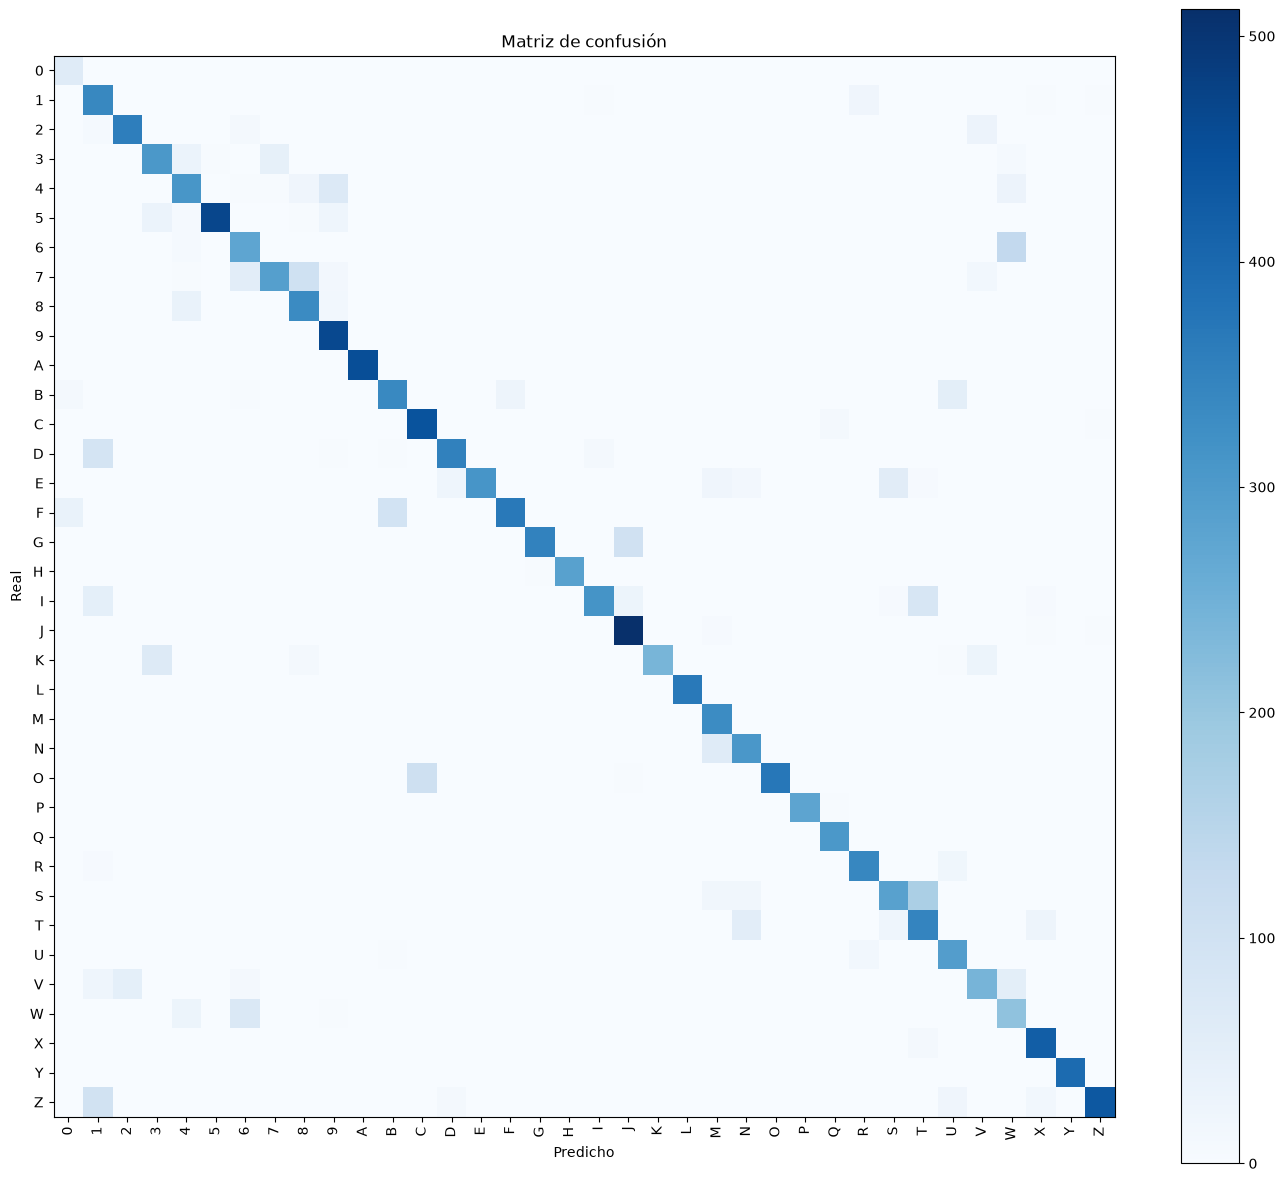

In [31]:
import torchmetrics
import matplotlib.pyplot as plt

num_clases = len(nombres_clases)

cm_metrics = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=num_clases)
matriz = cm_metrics(y_pred, y_true)

# Visualizar como mapa de calor
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(matriz, cmap='Blues')
ax.set_xticks(range(num_clases)); ax.set_xticklabels(nombres_clases, rotation=90)
ax.set_yticks(range(num_clases)); ax.set_yticklabels(nombres_clases)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusión')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=100)
plt.show()

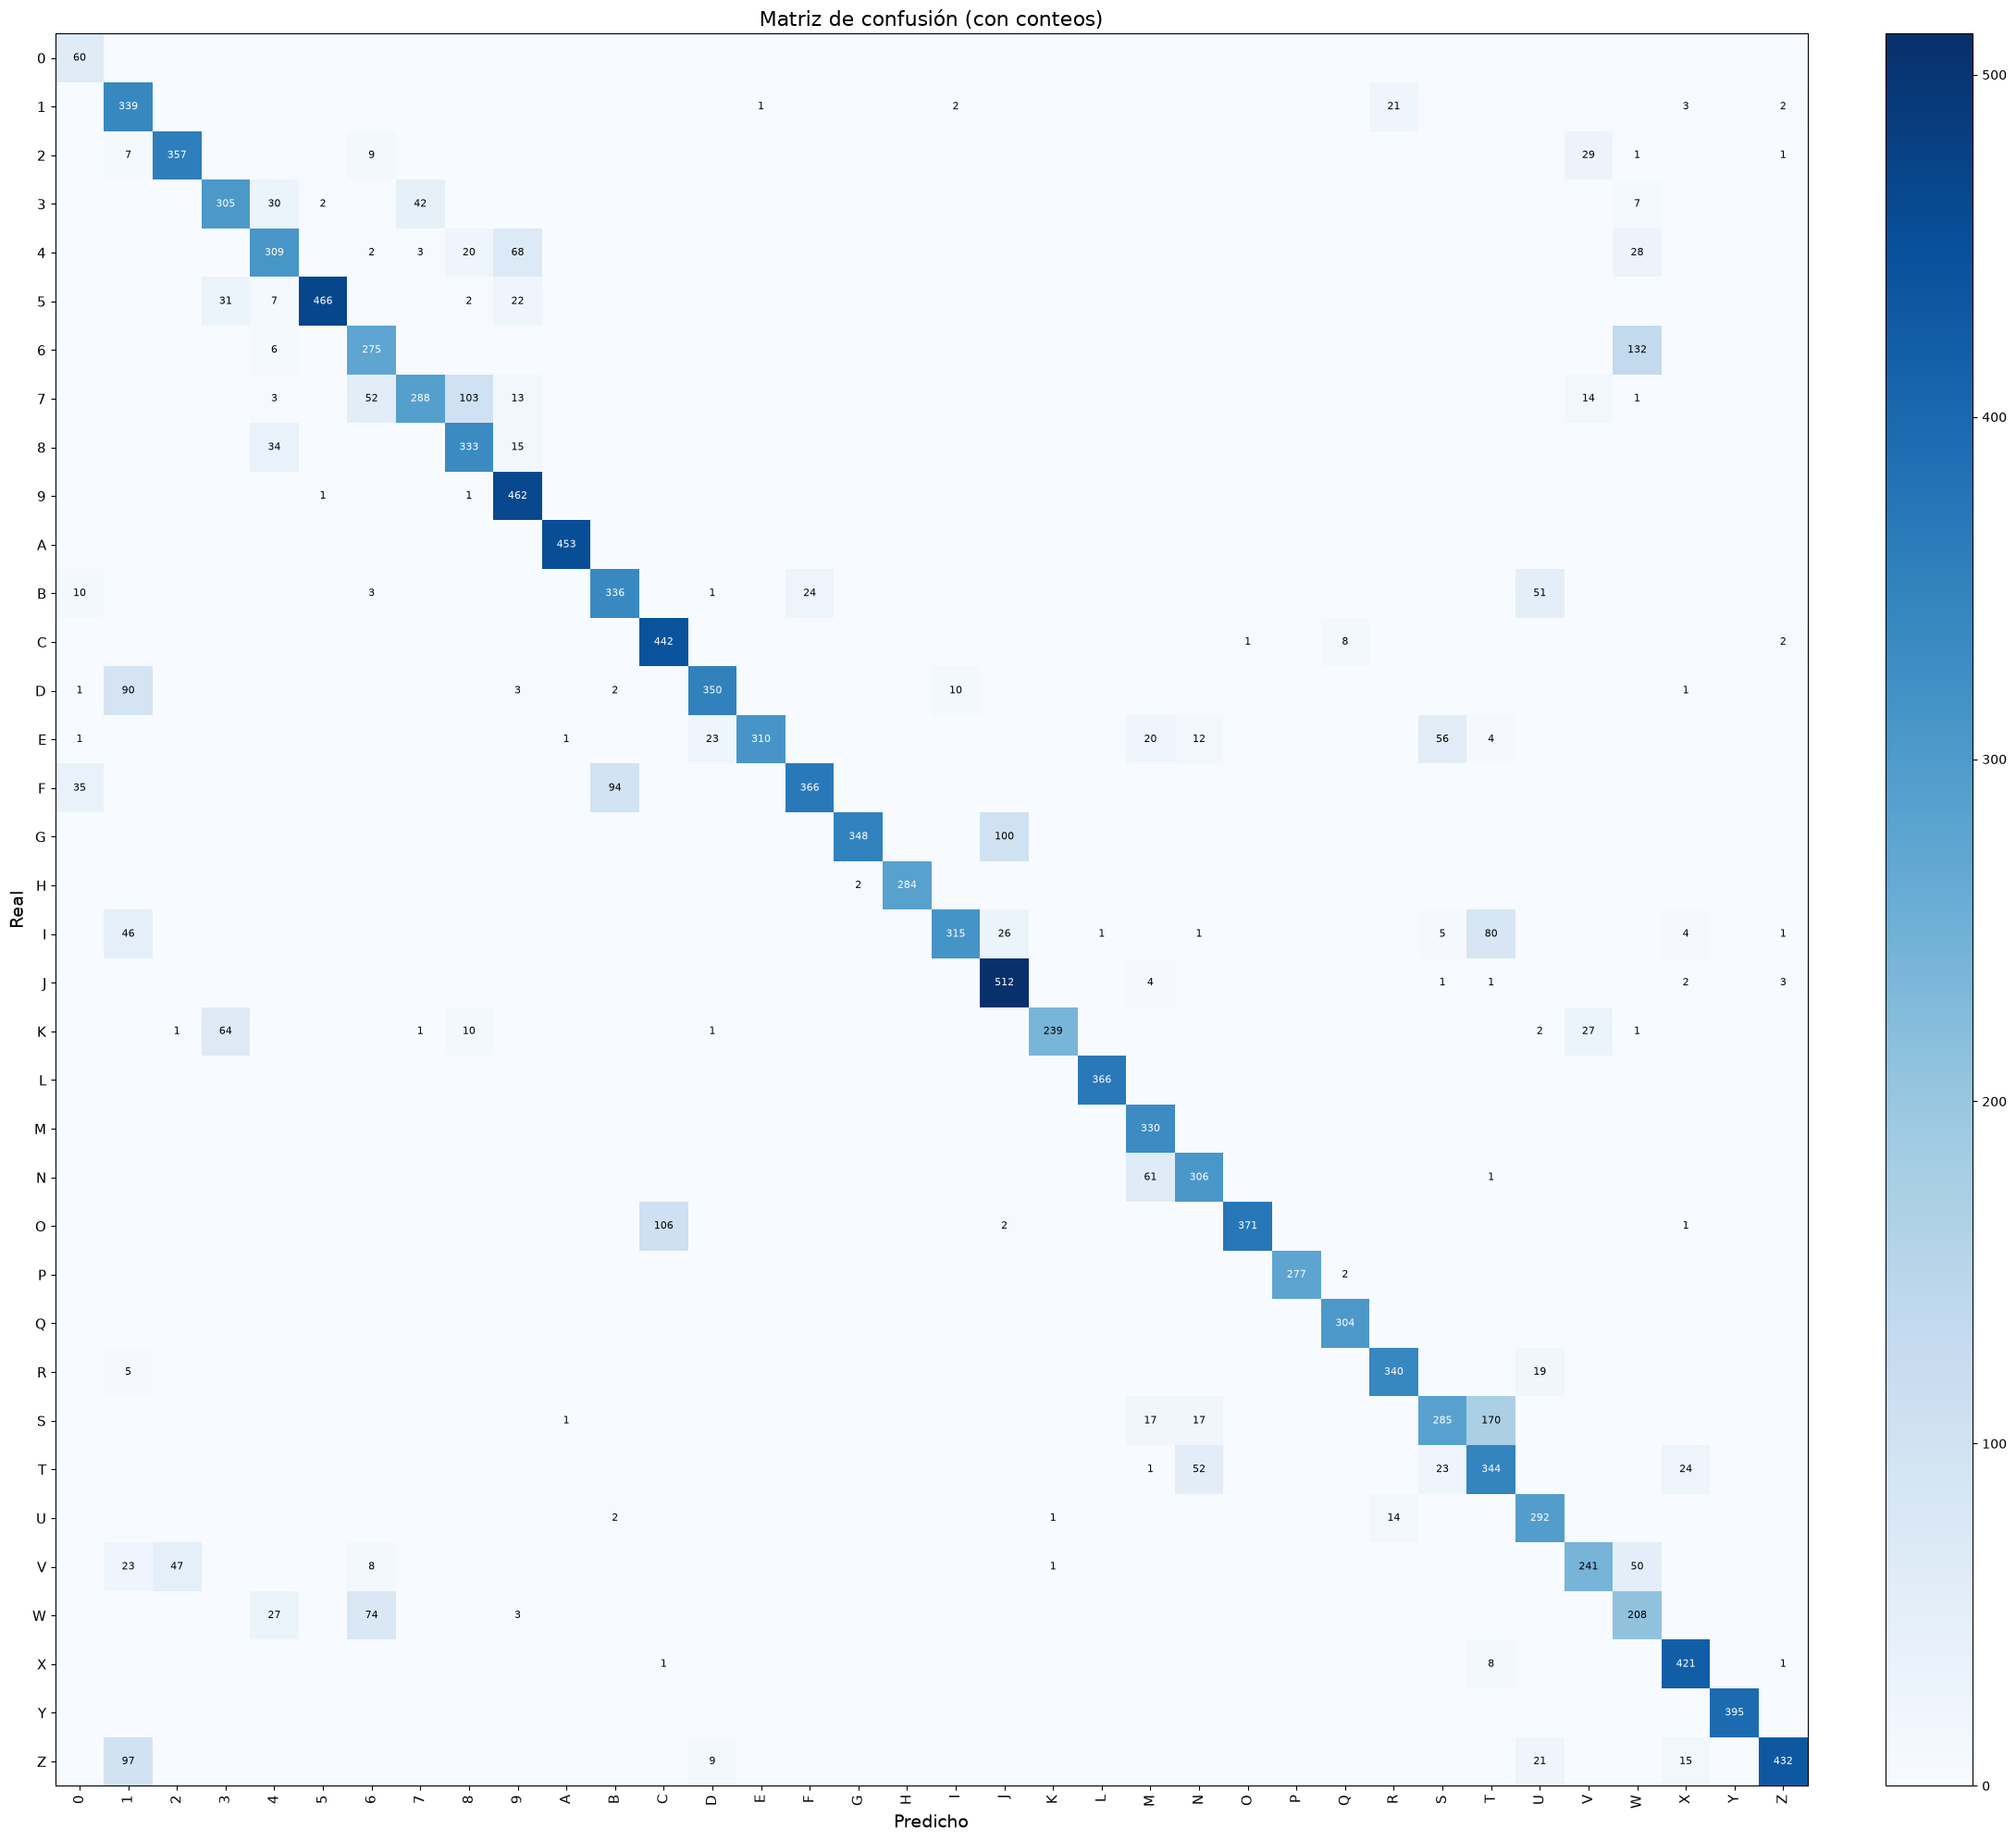

In [32]:
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

num_clases = len(nombres_clases)
cm_metric = torchmetrics.ConfusionMatrix(task="multiclass", num_classes=num_clases)
matriz = cm_metric(y_pred, y_true).numpy()   # a numpy para manejarla fácil

# Figura grande: ~0.6 pulgadas por clase, para que quepan los números
fig, ax = plt.subplots(figsize=(22, 20))
im = ax.imshow(matriz, cmap='Blues')

# Ejes con nombres de clases
ax.set_xticks(range(num_clases)); ax.set_xticklabels(nombres_clases, rotation=90, fontsize=11)
ax.set_yticks(range(num_clases)); ax.set_yticklabels(nombres_clases, fontsize=11)
ax.set_xlabel('Predicho', fontsize=14)
ax.set_ylabel('Real', fontsize=14)
ax.set_title('Matriz de confusión (con conteos)', fontsize=16)

# Escribir el número en cada celda
umbral = matriz.max() / 2   # para decidir color del texto según el fondo
for i in range(num_clases):
    for j in range(num_clases):
        valor = matriz[i, j]
        if valor > 0:   # solo mostrar celdas con al menos una predicción
            ax.text(j, i, int(valor),
                    ha='center', va='center', fontsize=8,
                    color='white' if valor > umbral else 'black')

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('matriz_confusion_numeros.png', dpi=120, bbox_inches='tight')
plt.show()

In [37]:
import torchmetrics

num_clases = len(nombres_clases)
cm_metric = torchmetrics.ConfusionMatrix(task="multiclass", num_classes=num_clases)
matriz = cm_metric(y_pred, y_true).numpy()

# Ancho de cada celda (ajusta si tus nombres son más largos)
w = 4

# Encabezado: nombres de clases predichas arriba
encabezado = " " * 6 + "".join(f"{c:>{w}}" for c in nombres_clases)
print("Predicho →")
print(encabezado)
print("Real ↓")

# Cada fila: nombre de la clase real + sus conteos
for i, clase_real in enumerate(nombres_clases):
    fila = f"{clase_real:>5} " + "".join(f"{int(matriz[i, j]):>{w}}" for j in range(num_clases))
    print(fila)

Predicho →
         0   1   2   3   4   5   6   7   8   9   A   B   C   D   E   F   G   H   I   J   K   L   M   N   O   P   Q   R   S   T   U   V   W   X   Y   Z
Real ↓
    0   60   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    1    0 339   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   2   0   0   0   0   0   0   0   0  21   0   0   0   0   0   3   0   2
    2    0   7 357   0   0   0   9   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  29   1   0   0   1
    3    0   0   0 305  30   2   0  42   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   7   0   0   0
    4    0   0   0   0 309   0   2   3  20  68   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  28   0   0   0
    5    0   0   0  31   7 466   0   0   2  22   0   0   0   0   0   0   0  

## `classification_report`

In [39]:
from sklearn.metrics import classification_report

reporte = classification_report(
    y_true.numpy(), y_pred.numpy(),
    target_names=nombres_clases,
    digits=3
)
print(reporte)

              precision    recall  f1-score   support

           0      0.561     1.000     0.719        60
           1      0.558     0.921     0.695       368
           2      0.881     0.884     0.883       404
           3      0.762     0.790     0.776       386
           4      0.743     0.719     0.730       430
           5      0.994     0.883     0.935       528
           6      0.650     0.666     0.658       413
           7      0.862     0.608     0.713       474
           8      0.710     0.872     0.783       382
           9      0.788     0.996     0.880       464
           A      0.996     1.000     0.998       453
           B      0.774     0.791     0.782       425
           C      0.805     0.976     0.882       453
           D      0.911     0.766     0.832       457
           E      0.997     0.726     0.840       427
           F      0.938     0.739     0.827       495
           G      0.994     0.777     0.872       448
           H      1.000    

## Inspección visual de errores

Total de errores: 2456 de 14517


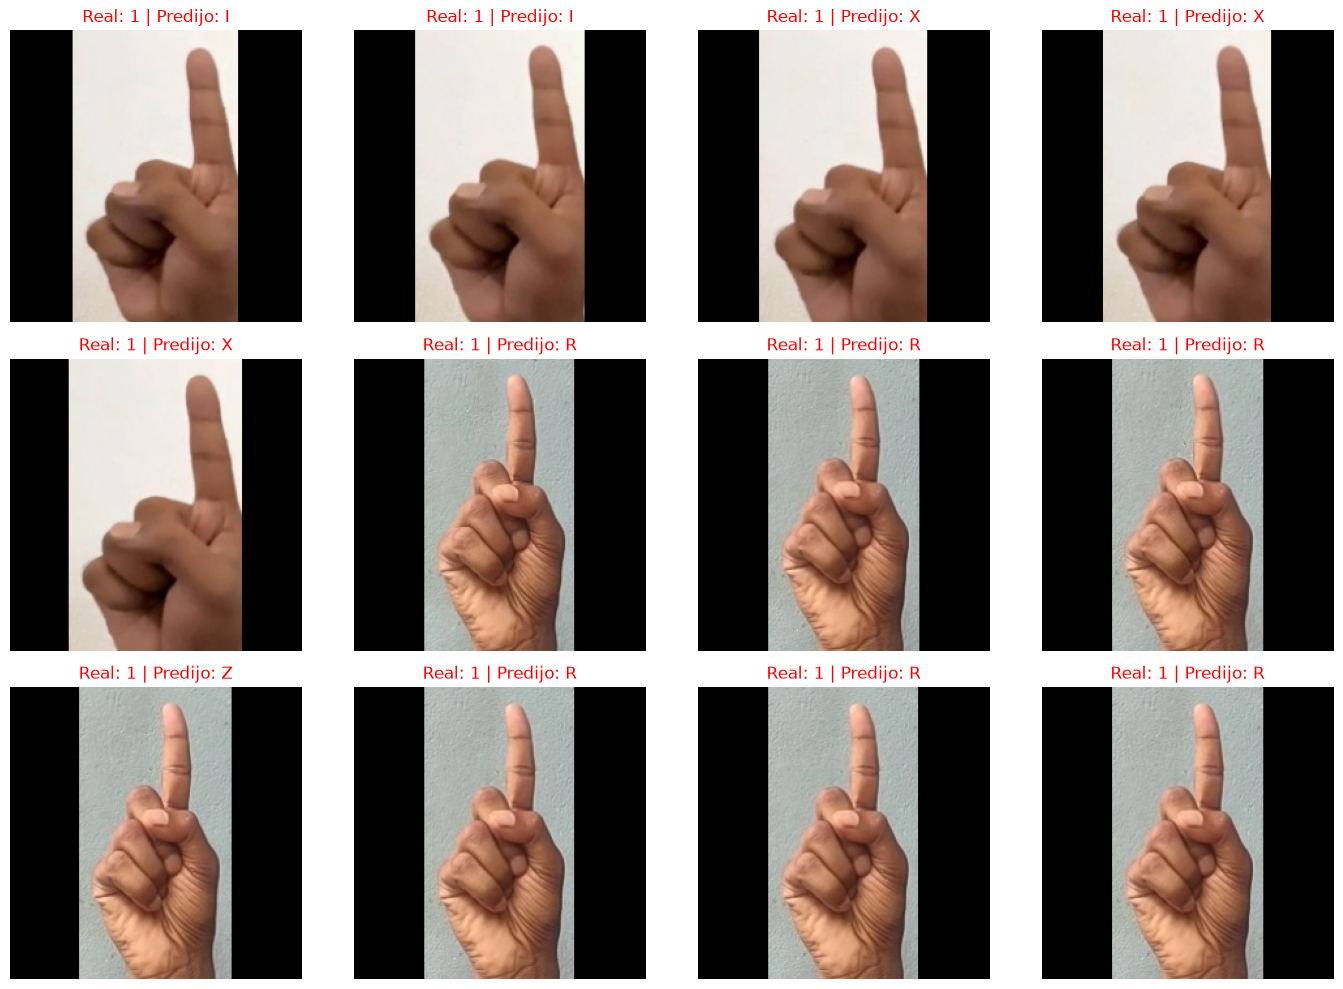

In [40]:
import numpy as np

# Encontrar los índices donde el modelo falló
errores = (y_pred != y_true).nonzero(as_tuple=True)[0]
print(f"Total de errores: {len(errores)} de {len(y_true)}")

# Mostrar los primeros 12 errores
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
dataset = test_loader.dataset

for ax, idx in zip(axes.flat, errores[:12]):
    imagen, etiqueta_real = dataset[idx]        # recarga la imagen original
    # Deshacer la normalización para poder verla (aprox, solo para visualizar)
    img_vis = imagen.permute(1, 2, 0).numpy()
    img_vis = img_vis * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_vis = np.clip(img_vis, 0, 1)

    ax.imshow(img_vis)
    real = nombres_clases[y_true[idx]]
    pred = nombres_clases[y_pred[idx]]
    ax.set_title(f"Real: {real} | Predijo: {pred}", color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Medición de tiempo de inferencia

In [41]:
import time

model.eval()
una_imagen, _ = test_loader.dataset[0]
una_imagen = una_imagen.unsqueeze(0).to(device)   # añade dimensión de batch

# Calentamiento (las primeras inferencias son más lentas)
with torch.no_grad():
    for _ in range(5):
        _ = model(una_imagen)

# Medir
n = 100
inicio = time.time()
with torch.no_grad():
    for _ in range(n):
        _ = model(una_imagen)
tiempo_promedio = (time.time() - inicio) / n * 1000   # en milisegundos

print(f"Tiempo por imagen: {tiempo_promedio:.2f} ms")
print(f"Imágenes por segundo: {1000/tiempo_promedio:.1f}")

Tiempo por imagen: 6.96 ms
Imágenes por segundo: 143.7
